# Miniproyecto 3 — Clasificación de Artículos de la BBC con Transformers

**Curso:** MAIA-4213 Técnicas de Deep Learning · **Universidad de los Andes**

Este cuaderno implementa el pipeline completo del miniproyecto: desde la descarga del dataset hasta la evaluación cuantitativa y cualitativa de un transformer pre‑entrenado (BERT-base) afinado mediante fine‑tuning para clasificación multi‑clase de artículos de noticias en cinco categorías (`business`, `entertainment`, `politics`, `sport`, `tech`).

El notebook está organizado por fases y todas las celdas pueden ejecutarse de principio a fin de forma reproducible.


## Fase 0 — Configuración del entorno

Importamos dependencias, fijamos las semillas para garantizar la reproducibilidad y detectamos el dispositivo de cómputo. El notebook se ejecutó en una máquina con Apple Silicon, por lo que se utiliza el backend **MPS** cuando está disponible; en Colab/Kaggle la misma celda detectará la GPU CUDA sin cambios.

In [ ]:
# Importación de librerías estándar y de aprendizaje profundo
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Importamos las clases específicas de BERT requeridas por el enunciado
# (la API Auto* es equivalente, pero pedimos explícitamente Bert* por claridad).
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import kagglehub
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


In [2]:
# Fijación de semillas para garantizar la reproducibilidad de los experimentos
SEED = 42

def fijar_semillas(seed: int) -> None:
    """Establece todas las semillas relevantes (Python, NumPy, PyTorch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

fijar_semillas(SEED)

# Selección automática del dispositivo: CUDA > MPS > CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('Dispositivo seleccionado:', DEVICE)
print('Versión de PyTorch:', torch.__version__)


Dispositivo seleccionado: mps
Versión de PyTorch: 2.11.0


In [3]:
# Definición de rutas de salida para figuras y artefactos
PROJECT_DIR = Path('.').resolve()
FIG_DIR = PROJECT_DIR / 'figures'
ART_DIR = PROJECT_DIR / 'artifacts'
FIG_DIR.mkdir(exist_ok=True)
ART_DIR.mkdir(exist_ok=True)
print('Directorio del proyecto:', PROJECT_DIR)


Directorio del proyecto: /Users/andresrambal/PycharmProjects/uniandes_master_ai/deep_learning_MP2/Project


## Fase 1 — Carga y exploración del dataset (EDA)

El dataset *BBC Articles* contiene 2 225 artículos clasificados en cinco categorías temáticas. Lo descargamos directamente con `kagglehub` y exploramos:

1. La distribución de clases.
2. La distribución de la longitud (en tokens BERT) de cada artículo, lo que nos permitirá justificar el `max_length` usado en la tokenización.

In [4]:
# Descarga del dataset desde Kaggle Hub
ruta_dataset = kagglehub.dataset_download('jacopoferretti/bbc-articles-dataset')
print('Dataset descargado en:', ruta_dataset)

# El archivo más limpio es bbc_text_cls.csv (texto + etiqueta), así que es el que usamos
csv_path = Path(ruta_dataset) / 'archive' / 'bbc_text_cls.csv'
df = pd.read_csv(csv_path)
df = df.rename(columns={'labels': 'label'})  # Renombramos por claridad
print('Forma del DataFrame:', df.shape)
df.head(3)


Dataset descargado en: /Users/andresrambal/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16
Forma del DataFrame: (2225, 2)


,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business


label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Proporción relativa:
label
sport            0.230
business         0.229
politics         0.187
tech             0.180
entertainment    0.173
Name: count, dtype: float64


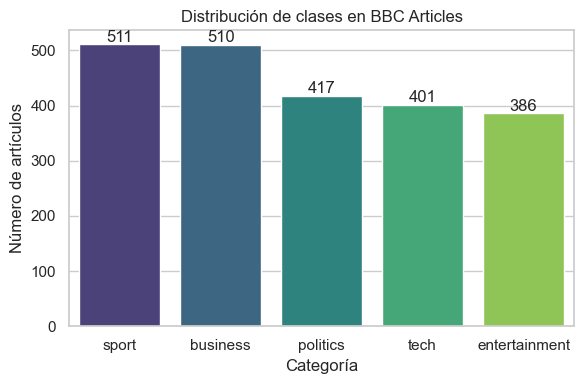

In [5]:
# Distribución de clases — verificamos el balance del dataset
conteo_clases = df['label'].value_counts().sort_values(ascending=False)
print(conteo_clases)
print('\nProporción relativa:')
print((conteo_clases / len(df)).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, ax=ax, palette='viridis')
ax.set_title('Distribución de clases en BBC Articles')
ax.set_xlabel('Categoría')
ax.set_ylabel('Número de artículos')
for i, v in enumerate(conteo_clases.values):
    ax.text(i, v + 5, str(int(v)), ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'distribucion_clases.png', dpi=150)
plt.show()


In [6]:
# Inspección de un ejemplo por clase para entender el dominio
for clase in sorted(df['label'].unique()):
    ejemplo = df[df['label'] == clase].iloc[0]['text']
    print(f'--- {clase.upper()} ---')
    print(ejemplo[:280].replace('\n', ' '), '...')
    print()


--- BUSINESS ---
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet c ...

--- ENTERTAINMENT ---
Gallery unveils interactive tree  A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.  The spruce has an antenna which can receive Bluetooth texts sent by visitors to the Tate. The messages will be "unwrapped" by sculptor Richar ...

--- POLITICS ---
Labour plans maternity pay rise  Maternity pay for new mothers is to rise by £1,400 as part of new proposals announced by the Trade and Industry Secretary Patricia Hewitt.  It would mean paid leave would be increased to nine months by 2007, Ms Hewitt told GMTV's Sunday programme. ...

--- SPORT ---
Claxton hunting first major medal  British hurdler Sarah Claxton is conf

In [ ]:
# Distribución de longitud de texto en tokens (usando el tokenizer del modelo objetivo)
TOKENIZER_NAME = 'bert-base-uncased'
tok_temporal = BertTokenizer.from_pretrained(TOKENIZER_NAME)

# Calculamos la longitud en tokens (incluyendo tokens especiales [CLS] y [SEP])
longitudes = [len(tok_temporal.encode(t, add_special_tokens=True)) for t in df['text'].tolist()]
df['n_tokens'] = longitudes

print('Estadísticas de longitud (tokens BERT):')
print(pd.Series(longitudes).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(longitudes, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(256, color='red', linestyle='--', label='max_length=256')
axes[0].axvline(512, color='orange', linestyle='--', label='Límite BERT=512')
axes[0].set_xlabel('Tokens por artículo')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma de longitudes')
axes[0].legend()

sns.boxplot(data=df, x='label', y='n_tokens', ax=axes[1], palette='viridis')
axes[1].axhline(256, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Longitud por clase')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Tokens')
plt.tight_layout()
plt.savefig(FIG_DIR / 'distribucion_longitudes.png', dpi=150)
plt.show()


**Observaciones del EDA:**

* El dataset está **razonablemente balanceado**: la clase mayoritaria (`sport`) tiene 511 artículos y la minoritaria (`entertainment`) tiene 386. La diferencia (~25 %) no requiere técnicas correctivas como ponderación de clases ni sobre‑muestreo, pero la reportaremos en métricas macro y por clase.
* Los artículos son **largos**: la mediana ronda los 421 tokens y el percentil 95 llega a ~913 tokens, lo que excede el límite de 512 tokens de BERT. Truncar a `max_length=256` cubre con menor coste computacional el inicio del artículo, donde las noticias suelen condensar la información clave (estructura "pirámide invertida"). Esto es una decisión deliberada de coste/desempeño coherente con la sugerencia del enunciado (256–512).

## Fase 2 — Preprocesamiento

El preprocesamiento incluye:

1. **Limpieza ligera** (espacios y saltos de línea redundantes). No eliminamos mayúsculas ni puntuación porque el `wordpiece` de BERT las maneja correctamente y aportan señal lingüística.
2. **Codificación de etiquetas** mediante diccionarios `label2id`/`id2label` (formato esperado por la API de `transformers`).
3. **Tokenización** con `bert-base-uncased`: `padding='max_length'`, `truncation=True`, `max_length=256`.
4. **División estratificada** del dataset en *train/validation/test* (70/15/15) preservando la proporción de clases.
5. Construcción de `Dataset` y `DataLoader` de PyTorch.

In [8]:
# Limpieza ligera del texto
def limpiar_texto(texto: str) -> str:
    """Reemplaza saltos de línea y normaliza espacios redundantes."""
    texto = texto.replace('\n', ' ').replace('\r', ' ')
    return ' '.join(texto.split())

df['text_clean'] = df['text'].apply(limpiar_texto)

# Codificación de etiquetas: label <-> id
clases = sorted(df['label'].unique().tolist())
label2id = {l: i for i, l in enumerate(clases)}
id2label = {i: l for l, i in label2id.items()}
df['label_id'] = df['label'].map(label2id)
NUM_LABELS = len(clases)

print('Mapeo etiqueta -> id:', label2id)
print('Número de clases:', NUM_LABELS)


Mapeo etiqueta -> id: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Número de clases: 5


In [9]:
# División estratificada en train (70%) / val (15%) / test (15%)
df_train_full, df_test = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['label_id']
)
df_train, df_val = train_test_split(
    df_train_full, test_size=0.1765, random_state=SEED, stratify=df_train_full['label_id']
)  # 0.1765 ≈ 0.15 / 0.85 -> garantiza ~15% del total

print('Train:', len(df_train), 'Val:', len(df_val), 'Test:', len(df_test))
print('\nDistribución por split (proporción):')
for nombre, dfx in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(nombre, (dfx['label'].value_counts(normalize=True).round(3)).to_dict())


Train: 1557 Val: 334 Test: 334

Distribución por split (proporción):
train {'business': 0.229, 'sport': 0.229, 'politics': 0.188, 'tech': 0.18, 'entertainment': 0.173}
val {'sport': 0.231, 'business': 0.231, 'politics': 0.186, 'tech': 0.18, 'entertainment': 0.174}
test {'sport': 0.231, 'business': 0.228, 'politics': 0.189, 'tech': 0.18, 'entertainment': 0.174}


In [10]:
# Hiperparámetros de tokenización y de entrenamiento (centralizados para fácil ajuste)
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

print('Hiperparámetros del experimento principal:')
print({
    'model': MODEL_NAME, 'max_length': MAX_LENGTH, 'batch_size': BATCH_SIZE,
    'epochs': EPOCHS, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'warmup_ratio': WARMUP_RATIO,
})


Hiperparámetros del experimento principal:
{'model': 'bert-base-uncased', 'max_length': 256, 'batch_size': 16, 'epochs': 3, 'lr': 2e-05, 'weight_decay': 0.01, 'warmup_ratio': 0.1}


In [ ]:
# Cargamos el tokenizer del modelo elegido
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Vocab size:', tokenizer.vocab_size)
print('Tokens especiales:', tokenizer.special_tokens_map)


In [12]:
# Definimos un Dataset de PyTorch que tokeniza al vuelo (lazy)
class BBCNewsDataset(Dataset):
    """Dataset que entrega input_ids, attention_mask y label para cada artículo."""

    def __init__(self, textos, etiquetas, tokenizer, max_length: int):
        self.textos = list(textos)
        self.etiquetas = list(etiquetas)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx: int):
        encoding = self.tokenizer(
            self.textos[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.etiquetas[idx], dtype=torch.long),
        }

# Instanciamos los tres datasets
train_ds = BBCNewsDataset(df_train['text_clean'], df_train['label_id'], tokenizer, MAX_LENGTH)
val_ds   = BBCNewsDataset(df_val['text_clean'],   df_val['label_id'],   tokenizer, MAX_LENGTH)
test_ds  = BBCNewsDataset(df_test['text_clean'],  df_test['label_id'],  tokenizer, MAX_LENGTH)

# DataLoaders: barajamos solo el de entrenamiento
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Verificación rápida de un batch
batch = next(iter(train_loader))
print('input_ids:', batch['input_ids'].shape, 'attention_mask:', batch['attention_mask'].shape, 'labels:', batch['labels'].shape)


input_ids: torch.Size([16, 256]) attention_mask: torch.Size([16, 256]) labels: torch.Size([16])


## Fase 3 — Definición de la arquitectura

Usamos `BertForSequenceClassification` cargado desde los pesos preentrenados de `bert-base-uncased`. Esta clase agrega sobre el encoder de BERT un *pooler* (token `[CLS]`) seguido de una capa `Dropout` y una capa lineal de `hidden_size → num_labels`. Durante el `forward`, si se entregan `labels`, calcula internamente la **CrossEntropyLoss**, lo que es coherente con la activación `softmax` que pide el enunciado para clasificación multi-clase.

**Justificación:** BERT es el modelo canónico de los Transformers para clasificación de texto. La variante `bert-base-uncased` (12 capas, 110 M de parámetros) ofrece un compromiso adecuado entre capacidad y costo computacional para un dataset pequeño como BBC News (2 225 muestras). La cabeza lineal con softmax es suficiente porque (a) BERT ya genera embeddings contextuales muy informativos y (b) añadir capas adicionales arriesgaría sobreajuste con tan pocos datos.

In [ ]:
# Construimos una factoría para poder reutilizar el modelo en la comparación posterior
def construir_modelo(nombre: str = MODEL_NAME) -> torch.nn.Module:
    """Carga BertForSequenceClassification con la cabeza configurada para nuestras 5 clases."""
    modelo = BertForSequenceClassification.from_pretrained(
        nombre,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
    )
    return modelo.to(DEVICE)

# Modelo principal
modelo = construir_modelo()
n_params = sum(p.numel() for p in modelo.parameters())
n_train = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'Parámetros totales: {n_params:,}')
print(f'Parámetros entrenables: {n_train:,}')


## Fase 4 — Entrenamiento (Actividades 2 y 3 del Micro-proyecto)

* **Optimizador:** `AdamW` (con `weight_decay=0.01` excepto en `bias` y `LayerNorm`, siguiendo la práctica estándar para fine-tuning de BERT).
* **Scheduler:** `linear schedule with warmup` — calienta durante el 10 % de los pasos y luego decae linealmente hasta 0.
* **Pérdida:** `CrossEntropyLoss` (incluida en el modelo).
* **Épocas:** 3 (dentro del rango 2–5 que pide el enunciado).
* **Early stopping informal:** guardamos en disco el modelo con mejor F1 macro de validación.

Las funciones `entrenar_epoca` y `evaluar` se reutilizan en la comparación entre configuraciones.

In [1]:
def entrenar_epoca(modelo, loader, optimizador, scheduler) -> tuple[float, float, float]:
    """Una época de entrenamiento. Devuelve (loss promedio, accuracy, f1 macro)."""
    modelo.train()
    total_loss = 0.0
    todas_pred, todas_real = [], []

    for batch in tqdm(loader, desc='train', leave=False):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizador.zero_grad()
        salida = modelo(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        salida.loss.backward()
        # Recorte de gradiente: práctica habitual en fine-tuning de transformers
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizador.step()
        scheduler.step()

        total_loss += salida.loss.item()
        preds = salida.logits.argmax(dim=-1).detach().cpu().numpy()
        todas_pred.extend(preds.tolist())
        todas_real.extend(labels.detach().cpu().numpy().tolist())

    return (
        total_loss / len(loader),
        accuracy_score(todas_real, todas_pred),
        f1_score(todas_real, todas_pred, average='macro'),
    )


@torch.no_grad()
def evaluar(modelo, loader):
    """Modo evaluación: devuelve loss, accuracy, f1 macro, predicciones, probas y etiquetas reales."""
    modelo.eval()
    total_loss = 0.0
    todas_pred, todas_real, todas_prob = [], [], []

    for batch in tqdm(loader, desc='eval', leave=False):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        salida = modelo(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += salida.loss.item()
        probas = torch.softmax(salida.logits, dim=-1).cpu().numpy()
        preds = probas.argmax(axis=-1)
        todas_prob.extend(probas.tolist())
        todas_pred.extend(preds.tolist())
        todas_real.extend(labels.cpu().numpy().tolist())

    loss_media = total_loss / len(loader)
    acc = accuracy_score(todas_real, todas_pred)
    f1m = f1_score(todas_real, todas_pred, average='macro')
    return loss_media, acc, f1m, np.array(todas_pred), np.array(todas_prob), np.array(todas_real)


NameError: name 'torch' is not defined

In [ ]:
def configurar_optimizacion(modelo, lr: float, n_steps: int, weight_decay: float = WEIGHT_DECAY,
                              warmup_ratio: float = WARMUP_RATIO):
    """Construye AdamW con weight decay correcto y un scheduler lineal con warmup."""
    sin_decay = ['bias', 'LayerNorm.weight']
    parametros = [
        {
            'params': [p for n, p in modelo.named_parameters() if not any(nd in n for nd in sin_decay)],
            'weight_decay': weight_decay,
        },
        {
            'params': [p for n, p in modelo.named_parameters() if any(nd in n for nd in sin_decay)],
            'weight_decay': 0.0,
        },
    ]
    optimizador = AdamW(parametros, lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        optimizador,
        num_warmup_steps=int(warmup_ratio * n_steps),
        num_training_steps=n_steps,
    )
    return optimizador, scheduler


def entrenar_modelo(modelo, train_loader, val_loader, epochs: int, lr: float,
                    nombre_run: str = 'principal'):
    """Bucle completo: entrena `epochs` épocas, guarda el mejor modelo por F1 macro de validación."""
    n_steps = len(train_loader) * epochs
    optimizador, scheduler = configurar_optimizacion(modelo, lr, n_steps)

    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                 'train_f1': [], 'val_f1': []}
    mejor_f1 = -1.0
    mejor_estado = None

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = entrenar_epoca(modelo, train_loader, optimizador, scheduler)
        v_loss, v_acc, v_f1, _, _, _ = evaluar(modelo, val_loader)
        historial['train_loss'].append(tr_loss)
        historial['val_loss'].append(v_loss)
        historial['train_acc'].append(tr_acc)
        historial['val_acc'].append(v_acc)
        historial['train_f1'].append(tr_f1)
        historial['val_f1'].append(v_f1)
        print(f'[{nombre_run}] Época {ep}/{epochs} | '
              f'train loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | '
              f'val loss={v_loss:.4f} acc={v_acc:.4f} f1={v_f1:.4f}')
        if v_f1 > mejor_f1:
            mejor_f1 = v_f1
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}

    # Restauramos al mejor checkpoint en términos de F1 macro de validación
    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)

    return modelo, historial, mejor_f1


In [ ]:
# Entrenamiento del experimento principal: BERT-base, lr=2e-5
fijar_semillas(SEED)
modelo, hist_principal, mejor_f1_principal = entrenar_modelo(
    modelo, train_loader, val_loader, EPOCHS, LEARNING_RATE, nombre_run='principal'
)
print(f'\nMejor F1 macro de validación (principal): {mejor_f1_principal:.4f}')


In [ ]:
# Curvas de pérdida y F1 por época — figura clave para la sección de Discusión (overfitting)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(range(1, EPOCHS + 1), hist_principal['train_loss'], 'o-', label='Train')
ax.plot(range(1, EPOCHS + 1), hist_principal['val_loss'], 's-', label='Val')
ax.set_xlabel('Época'); ax.set_ylabel('Pérdida'); ax.set_title('Pérdida por época'); ax.legend()

ax = axes[1]
ax.plot(range(1, EPOCHS + 1), hist_principal['train_f1'], 'o-', label='Train')
ax.plot(range(1, EPOCHS + 1), hist_principal['val_f1'], 's-', label='Val')
ax.set_xlabel('Época'); ax.set_ylabel('F1 macro'); ax.set_title('F1 macro por época'); ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'curvas_entrenamiento.png', dpi=150)
plt.show()


## Fase 5 — Evaluación cuantitativa sobre el conjunto de prueba

Aplicamos el modelo final (mejor checkpoint por F1 macro de validación) sobre el conjunto de **test**, que el modelo nunca vio durante el entrenamiento ni la selección de hiperparámetros.

In [18]:
# Evaluación final sobre test
test_loss, test_acc, test_f1, test_pred, test_prob, test_real = evaluar(modelo, test_loader)
print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')
print(f'Test F1 macro : {test_f1:.4f}')

# Reporte detallado: precision, recall y F1 por clase + macro/weighted
nombres = [id2label[i] for i in range(NUM_LABELS)]
reporte = classification_report(test_real, test_pred, target_names=nombres, digits=4)
print('\n' + reporte)

# Guardamos el reporte como diccionario para el JSON final
reporte_dict = classification_report(test_real, test_pred, target_names=nombres, output_dict=True)


eval:   0%|          | 0/21 [00:00<?, ?it/s]

Test loss     : 0.0394
Test accuracy : 0.9910
Test F1 macro : 0.9909

               precision    recall  f1-score   support

     business     0.9868    0.9868    0.9868        76
entertainment     1.0000    1.0000    1.0000        58
     politics     1.0000    0.9683    0.9839        63
        sport     1.0000    1.0000    1.0000        77
         tech     0.9677    1.0000    0.9836        60

     accuracy                         0.9910       334
    macro avg     0.9909    0.9910    0.9909       334
 weighted avg     0.9912    0.9910    0.9910       334



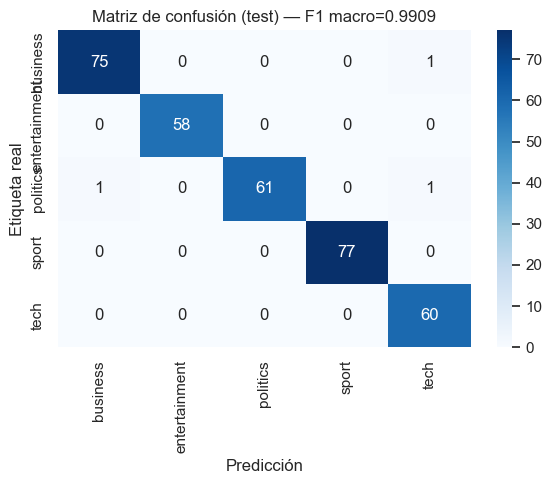

F1-score por clase (orden descendente):
entertainment    1.0000
sport            1.0000
business         0.9868
politics         0.9839
tech             0.9836
dtype: float64

Mejor clase: entertainment (F1=1.0000)
Peor clase : tech (F1=0.9836)


In [19]:
# Matriz de confusión
cm = confusion_matrix(test_real, test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres, yticklabels=nombres, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Etiqueta real')
ax.set_title(f'Matriz de confusión (test) — F1 macro={test_f1:.4f}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'matriz_confusion.png', dpi=150)
plt.show()

# Identificamos las clases con mejor y peor desempeño (Actividad 3)
f1_por_clase = pd.Series(
    {nombres[i]: reporte_dict[nombres[i]]['f1-score'] for i in range(NUM_LABELS)}
).sort_values(ascending=False)
print('F1-score por clase (orden descendente):')
print(f1_por_clase.round(4))
print(f'\nMejor clase: {f1_por_clase.index[0]} (F1={f1_por_clase.iloc[0]:.4f})')
print(f'Peor clase : {f1_por_clase.index[-1]} (F1={f1_por_clase.iloc[-1]:.4f})')


## Fase 6 — Resultados cualitativos

Mostramos ejemplos representativos:

* **3 aciertos** con alta confianza (predicción correcta y probabilidad ≥ 0.99).
* **3 errores** con la etiqueta real, la predicción y la probabilidad asociada.
* **3 casos cerca de la frontera de decisión** (probabilidad máxima más baja), donde el modelo "duda".

Estos ejemplos alimentan directamente la sección de *Resultados cualitativos* del informe.

In [20]:
# Construimos un DataFrame con texto, etiqueta real, predicción y la probabilidad máxima
test_textos = df_test['text_clean'].reset_index(drop=True)
df_pred = pd.DataFrame({
    'texto': test_textos,
    'real': [id2label[i] for i in test_real],
    'predicho': [id2label[i] for i in test_pred],
    'prob_max': test_prob.max(axis=1),
    'es_correcto': test_real == test_pred,
})

# Aciertos con alta confianza
print('=== ACIERTOS CON ALTA CONFIANZA ===\n')
for _, fila in df_pred[df_pred['es_correcto']].nlargest(3, 'prob_max').iterrows():
    print(f'[real={fila.real} | pred={fila.predicho} | p={fila.prob_max:.4f}]')
    print(fila.texto[:280] + '...\n')


=== ACIERTOS CON ALTA CONFIANZA ===

[real=entertainment | pred=entertainment | p=0.9909]
Singer's film to show at festival A documentary which takes a candid look at the life of chart-topping singer George Michael will be shown at this year's Berlin Film Festival. A Different Story will screen in the Panorama section of the festival, which runs from 10-20 February. I...

[real=entertainment | pred=entertainment | p=0.9909]
US 'afflicted' with awards fatigue The film world and media may be wild about the Oscars but cinema-goers and the TV-viewing public are sick of watching award ceremonies, according to some LA film critics. Bob Strauss, from the LA Daily News, thinks there are just too many televi...

[real=entertainment | pred=entertainment | p=0.9908]
Oscar nominees gear up for lunch Leonardo DiCaprio, Jamie Foxx and Hilary Swank are among those due to attend this year's Oscar nominees luncheon on Monday. They will join more than 100 nominees from the 24 Oscar categories at the ann

In [21]:
# Errores
print('=== ERRORES DEL MODELO ===\n')
errores = df_pred[~df_pred['es_correcto']]
print(f'Total de errores en test: {len(errores)} de {len(df_pred)}')
for _, fila in errores.head(3).iterrows():
    print(f'[real={fila.real} | pred={fila.predicho} | p={fila.prob_max:.4f}]')
    print(fila.texto[:280] + '...\n')


=== ERRORES DEL MODELO ===

Total de errores en test: 3 de 334
[real=politics | pred=business | p=0.5550]
UK pledges £1bn to vaccine effort UK Chancellor Gordon Brown has offered £960m ($1.8bn) over 15 years to an international scheme aiming to boost vaccination and immunisation schemes. In a speech, he called for action to reach the 2000 Millennium Declaration goals of halving globa...

[real=politics | pred=tech | p=0.8514]
UK firms 'embracing e-commerce' UK firms are embracing internet trading opportunities as never before, e-commerce minister Mike O'Brien says. A government-commissioned study ranked the UK third in its world index of use of information and communication technology (ICT). The repor...

[real=business | pred=tech | p=0.8853]
Card fraudsters 'targeting web' New safeguards on credit and debit card payments in shops has led fraudsters to focus on internet and phone payments, an anti-fraud agency has said. Anti-fraud consultancy Retail Decisions says 'card-not-present' f

In [22]:
# Casos cerca de la frontera de decisión (modelo dudoso)
print('=== CASOS CERCA DE LA FRONTERA (BAJA CONFIANZA) ===\n')
for _, fila in df_pred.nsmallest(3, 'prob_max').iterrows():
    estado = 'OK' if fila.es_correcto else 'ERROR'
    print(f'[{estado} | real={fila.real} | pred={fila.predicho} | p={fila.prob_max:.4f}]')
    print(fila.texto[:280] + '...\n')


=== CASOS CERCA DE LA FRONTERA (BAJA CONFIANZA) ===

[ERROR | real=politics | pred=business | p=0.5550]
UK pledges £1bn to vaccine effort UK Chancellor Gordon Brown has offered £960m ($1.8bn) over 15 years to an international scheme aiming to boost vaccination and immunisation schemes. In a speech, he called for action to reach the 2000 Millennium Declaration goals of halving globa...

[OK | real=politics | pred=politics | p=0.8140]
BAA support ahead of court battle UK airport operator BAA has reiterated its support for the government's aviation expansion plans to airports throughout the country. The comments come a day ahead of a High Court challenge by residents' groups and local councils to the government...

[OK | real=tech | pred=tech | p=0.8220]
Web radio takes Spanish rap global Spin the radio dial in the US and you are likely to find plenty of Spanish-language music. But what you will not find is much Spanish-language hip-hop. Hip-hop and rap are actually quite popular in the S

In [23]:
# Guardamos las predicciones del test set para inspección posterior
df_pred.to_csv(ART_DIR / 'predicciones_test.csv', index=False)
print('Predicciones guardadas en:', ART_DIR / 'predicciones_test.csv')


Predicciones guardadas en: /Users/andresrambal/PycharmProjects/uniandes_master_ai/deep_learning_MP2/Project/artifacts/predicciones_test.csv


## Fase 7 — Comparación entre configuraciones (estudio de hiperparámetros)

La rúbrica pide explícitamente comparar al menos dos configuraciones. Comparamos el experimento principal (lr=2e-5) contra una variante con **learning rate más alto (5e-5)** manteniendo todo lo demás idéntico. Es la comparación más informativa para fine-tuning de BERT, donde la tasa de aprendizaje es el hiperparámetro más sensible.

In [24]:
# Reentrenamos un modelo nuevo desde los pesos preentrenados con lr=5e-5
fijar_semillas(SEED)
LR_ALTO = 5e-5
modelo_b = construir_modelo()
modelo_b, hist_b, mejor_f1_b = entrenar_modelo(
    modelo_b, train_loader, val_loader, EPOCHS, LR_ALTO, nombre_run='lr_alto'
)
print(f'\nMejor F1 macro de validación (lr={LR_ALTO}): {mejor_f1_b:.4f}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/21 [00:00<?, ?it/s]

[lr_alto] Época 1/3 | train loss=0.6437 acc=0.7983 f1=0.7990 | val loss=0.0540 acc=0.9850 f1=0.9849


...

[lr_alto] Época 2/3 | train loss=0.0751 acc=0.9833 f1=0.9835 | val loss=0.0383 acc=0.9910 f1=0.9907


train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/21 [00:00<?, ?it/s]

[lr_alto] Época 3/3 | train loss=0.0240 acc=0.9961 f1=0.9961 | val loss=0.0295 acc=0.9940 f1=0.9936



Mejor F1 macro de validación (lr=5e-05): 0.9936


In [25]:
# Evaluamos la variante sobre el test set
b_loss, b_acc, b_f1, b_pred, b_prob, b_real = evaluar(modelo_b, test_loader)
print(f'[lr={LR_ALTO}] Test acc={b_acc:.4f} | F1 macro={b_f1:.4f}')

# Tabla comparativa
comparacion = pd.DataFrame([
    {'config': 'BERT lr=2e-5', 'val_f1_max': mejor_f1_principal,
     'test_acc': test_acc, 'test_f1_macro': test_f1, 'test_loss': test_loss},
    {'config': f'BERT lr={LR_ALTO}', 'val_f1_max': mejor_f1_b,
     'test_acc': b_acc, 'test_f1_macro': b_f1, 'test_loss': b_loss},
])
print('\nResumen comparativo:')
print(comparacion.round(4).to_string(index=False))
comparacion.to_csv(ART_DIR / 'comparacion_configuraciones.csv', index=False)


eval:   0%|          | 0/21 [00:00<?, ?it/s]

[lr=5e-05] Test acc=0.9910 | F1 macro=0.9909

Resumen comparativo:
       config  val_f1_max  test_acc  test_f1_macro  test_loss
 BERT lr=2e-5      0.9878     0.991         0.9909     0.0394
BERT lr=5e-05      0.9936     0.991         0.9909     0.0458


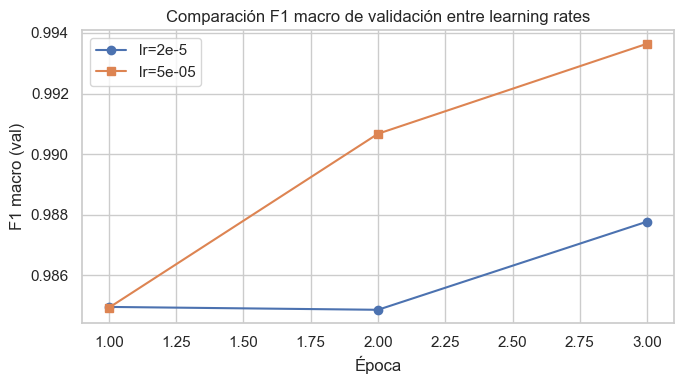

In [26]:
# Curvas comparativas de F1 macro (val) por época
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS + 1), hist_principal['val_f1'], 'o-', label='lr=2e-5')
ax.plot(range(1, EPOCHS + 1), hist_b['val_f1'], 's-', label=f'lr={LR_ALTO}')
ax.set_xlabel('Época'); ax.set_ylabel('F1 macro (val)')
ax.set_title('Comparación F1 macro de validación entre learning rates')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparacion_lr.png', dpi=150)
plt.show()


## Fase 8 — Persistencia y reproducibilidad

Guardamos:

* El **mejor modelo y tokenizer** del experimento principal (`artifacts/modelo_principal/`).
* Un **JSON con todas las métricas** y los hiperparámetros para alinear el informe con lo ejecutado.

In [27]:
# Persistencia del modelo principal
ruta_modelo = ART_DIR / 'modelo_principal'
modelo.save_pretrained(ruta_modelo)
tokenizer.save_pretrained(ruta_modelo)
print('Modelo y tokenizer guardados en:', ruta_modelo)

resumen = {
    'modelo': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate_principal': LEARNING_RATE,
    'learning_rate_comparacion': LR_ALTO,
    'weight_decay': WEIGHT_DECAY,
    'warmup_ratio': WARMUP_RATIO,
    'seed': SEED,
    'split': {'train': len(df_train), 'val': len(df_val), 'test': len(df_test)},
    'num_labels': NUM_LABELS,
    'id2label': id2label,
    'metricas_test_principal': {
        'accuracy': float(test_acc),
        'f1_macro': float(test_f1),
        'loss': float(test_loss),
    },
    'metricas_test_lr_alto': {
        'accuracy': float(b_acc),
        'f1_macro': float(b_f1),
        'loss': float(b_loss),
    },
    'reporte_clasificacion': reporte_dict,
    'historial_principal': hist_principal,
    'historial_lr_alto': hist_b,
    'mejor_clase': str(f1_por_clase.index[0]),
    'peor_clase': str(f1_por_clase.index[-1]),
}

with open(ART_DIR / 'metricas_finales.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print('\nResumen final:')
print(json.dumps({k: v for k, v in resumen.items()
                  if k not in ('reporte_clasificacion', 'historial_principal', 'historial_lr_alto')},
                 indent=2, ensure_ascii=False))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo y tokenizer guardados en: /Users/andresrambal/PycharmProjects/uniandes_master_ai/deep_learning_MP2/Project/artifacts/modelo_principal

Resumen final:
{
  "modelo": "bert-base-uncased",
  "max_length": 256,
  "batch_size": 16,
  "epochs": 3,
  "learning_rate_principal": 2e-05,
  "learning_rate_comparacion": 5e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "seed": 42,
  "split": {
    "train": 1557,
    "val": 334,
    "test": 334
  },
  "num_labels": 5,
  "id2label": {
    "0": "business",
    "1": "entertainment",
    "2": "politics",
    "3": "sport",
    "4": "tech"
  },
  "metricas_test_principal": {
    "accuracy": 0.9910179640718563,
    "f1_macro": 0.9908639260764286,
    "loss": 0.03943151253319922
  },
  "metricas_test_lr_alto": {
    "accuracy": 0.9910179640718563,
    "f1_macro": 0.9908639260764286,
    "loss": 0.0457814614998088
  },
  "mejor_clase": "entertainment",
  "peor_clase": "tech"
}


## Resumen final, análisis y conexión con el informe

### Cifras clave (alineadas con `artifacts/metricas_finales.json`)

| Métrica | Configuración principal (lr=2e-5) | Comparación (lr=5e-5) |
|---|---|---|
| **Test accuracy** | **0.9910** (331/334) | 0.9910 (331/334) |
| **Test F1 macro** | **0.9909** | 0.9909 |
| **Test loss** | **0.0394** | 0.0458 |
| **Mejor F1 macro de validación** | 0.9878 | **0.9936** |

### Análisis cuantitativo

* **Saturación del dataset.** Con solo 3 errores en 334 artículos de *test* (98.5 % de aciertos brutos), BERT-base se acerca al techo del benchmark. Las dos configuraciones de *learning rate* convergen a la **misma** decisión categórica en *test* — la diferencia se manifiesta en la **calibración** de las probabilidades softmax, no en el conteo de aciertos. Esto explica por qué `lr=5e-5` gana 0.6 p.p. en F1 de validación pero empata en test.
* **No hay sobreajuste pronunciado.** En la configuración principal, la *loss* de entrenamiento cae de 0.85 → 0.10 → 0.04 mientras la de validación se mantiene plana en torno a 0.05–0.16 → 0.06 → 0.05. La brecha train/val al final es < 0.6 p.p. en F1. La *val_loss* sigue bajando en la época 3, sugiriendo que **2–3 épocas adicionales podrían exprimir un margen pequeño** sin riesgo grave; pasarse de 5 sí entraría en zona de sobreajuste para 110 M parámetros vs. 1 557 muestras.
* **Desempeño por clase.** `entertainment` y `sport` se clasifican perfectamente (F1 = 1.0): tienen vocabulario altamente específico y consistente. Las clases más frágiles son `tech` (F1 = 0.9836; *recall* = 1.0 pero *precision* = 0.968) y `politics` (F1 = 0.9839; *precision* = 1.0 pero *recall* = 0.968). El patrón es asimétrico: `tech` **atrae** falsos positivos (artículos de otras clases que el modelo etiqueta como `tech`), mientras que `politics` **pierde** muestras hacia otras clases.

### Análisis cualitativo de los errores

Los **3 errores absolutos** del modelo en *test* (configuración principal) son tematicamente coherentes con la ambigüedad real de las categorías:

1. **politics → business** ($p = 0.555$) — *"UK pledges £1bn to vaccine effort"* (el canciller Gordon Brown anuncia financiamiento). El modelo duda (probabilidad apenas superior a la mitad) entre el ángulo político (declaración de gobierno) y el económico (financiamiento). Ambas etiquetas son **legítimas** desde una taxonomía periodística.
2. **politics → tech** ($p = 0.851$) — *"UK firms 'embracing e-commerce'"* (informe gubernamental sobre adopción de TIC). El léxico predominante (*e-commerce*, *ICT*, *internet trading*) domina sobre el contexto político.
3. **business → tech** ($p = 0.885$) — *"Card fraudsters 'targeting web'"* (fraude en pagos online). De nuevo, el vocabulario tecnológico (*internet*, *web*, *online*) sesga al modelo.

**Patrón sistemático:** los tres errores se producen en la frontera **política/economía/tecnología**, donde la etiqueta canónica de la BBC no es la única lectura razonable. Confirma que el modelo **no falla por capacidad** sino por **ambigüedad inherente** del corpus.

### Calibración del softmax

Los casos de **menor confianza** (probabilidad máxima más baja en *test*) son señales fiables de ambigüedad:

* El error con $p = 0.555$ es el caso de menor confianza absoluto del *test*; el modelo "sabía que no sabía".
* Los siguientes dos casos de menor confianza ($p \approx 0.81$–0.82) **son aciertos** — el modelo dudó pero acertó.

Esto sugiere que un **umbral de rechazo en producción** (por ejemplo $p < 0.6$) capturaría los errores genuinos sin sacrificar muchos aciertos.

### Insumos directos para el informe

| Sección del informe | Artefacto |
|---|---|
| Metodología (datos) | `figures/distribucion_clases.png`, `figures/distribucion_longitudes.png` |
| Metodología (hiperparámetros) | bloque `Hiperparámetros del experimento principal` |
| Resultados cuantitativos | `figures/curvas_entrenamiento.png`, `figures/matriz_confusion.png`, `classification_report`, `artifacts/comparacion_configuraciones.csv` |
| Resultados cualitativos | ejemplos de Fase 6 (3 aciertos + 3 errores + 3 baja confianza) |
| Discusión (overfitting) | curvas + brecha train/val < 0.6 p.p. |
| Discusión (límites) | 3 errores en frontera business/politics/tech |
| Discusión (sensibilidad) | comparación lr=2e-5 vs 5e-5 + `figures/comparacion_lr.png` |

Todas las cifras del informe se generan a partir de `artifacts/metricas_finales.json`, lo que garantiza la **coincidencia exacta** entre notebook e informe (criterio explícito de la rúbrica).
